In [2]:
from pathlib import Path
import shutil
# Original dataset
source = Path(r"D:\Users\91638\Downloads\archive (4)")

# Our project folder
destination = Path(r"D:\Users\91638\OneDrive\Desktop\Poverty_mapping\Raw_Dataset")

print("Source exists:", source.exists())
print("Destination exists:", destination.exists())


Source exists: True
Destination exists: False


In [3]:
import pandas as pd

data = []

for split in ["Train", "Validacion", "Prueba"]:
    for class_name in ["1", "2", "3"]:
        
        folder = source / split / class_name
        
        for image in folder.glob("*.jpg"):
            data.append({
                "original_split": split,
                "class": class_name,
                "image_path": str(image)
            })

df = pd.DataFrame(data)

df.head()

,original_split,class,image_path
0,Train,1,D:\Users\91638\Downloads\archive (4)\Train\1\1...
1,Train,1,D:\Users\91638\Downloads\archive (4)\Train\1\1...
2,Train,1,D:\Users\91638\Downloads\archive (4)\Train\1\1...
3,Train,1,D:\Users\91638\Downloads\archive (4)\Train\1\1...
4,Train,1,D:\Users\91638\Downloads\archive (4)\Train\1\1...


In [4]:
df.head()

,original_split,class,image_path
0,Train,1,D:\Users\91638\Downloads\archive (4)\Train\1\1...
1,Train,1,D:\Users\91638\Downloads\archive (4)\Train\1\1...
2,Train,1,D:\Users\91638\Downloads\archive (4)\Train\1\1...
3,Train,1,D:\Users\91638\Downloads\archive (4)\Train\1\1...
4,Train,1,D:\Users\91638\Downloads\archive (4)\Train\1\1...


In [5]:
print("Total Images:", len(df))

Total Images: 7473


In [6]:
df.groupby(["original_split", "class"]).size()

original_split  class
Prueba          1         194
                2         360
                3         200
Train           1        1354
                2        2628
                3        1400
Validacion      1         387
                2         550
                3         400
dtype: int64

In [7]:
# Create Class_1, Class_2 and Class_3 folders
for class_name in ["1", "2", "3"]:
    folder = destination / f"Class_{class_name}"
    folder.mkdir(parents=True, exist_ok=True)

print("Class folders created successfully!")

Class folders created successfully!


In [9]:
import shutil

for _, row in df.iterrows():
    source_file = Path(row["image_path"])
    class_folder = destination / f"Class_{row['class']}"
    
    # Create a unique filename to avoid duplicate filenames
    new_name = f"{row['original_split']}_{source_file.name}"
    destination_file = class_folder / new_name
    
    shutil.copy2(source_file, destination_file)

print("All images copied successfully!")

All images copied successfully!


In [10]:
for class_name in ["1", "2", "3"]:
    folder = destination / f"Class_{class_name}"
    count = len(list(folder.glob("*.jpg")))
    print(f"Class {class_name}: {count} images")

Class 1: 1935 images
Class 2: 3538 images
Class 3: 2000 images


In [11]:
from sklearn.model_selection import train_test_split

processed = Path(r"D:\Users\91638\OneDrive\Desktop\Poverty_mapping\Processed_Dataset")

# Create Train, Validation and Test folders
for split in ["Train", "Validation", "Test"]:
    for class_name in ["1", "2", "3"]:
        folder = processed / split / f"Class_{class_name}"
        folder.mkdir(parents=True, exist_ok=True)

print("Train, Validation and Test folders created successfully!")

Train, Validation and Test folders created successfully!


In [12]:
import random
import shutil

random.seed(42)

for class_name in ["1", "2", "3"]:
    
    # Get all images from the raw class folder
    class_folder = destination / f"Class_{class_name}"
    images = list(class_folder.glob("*.jpg"))
    
    # Shuffle the images
    random.shuffle(images)
    
    # Calculate split sizes
    total = len(images)
    train_end = int(total * 0.70)
    validation_end = train_end + int(total * 0.15)
    
    # Split the images
    train_images = images[:train_end]
    validation_images = images[train_end:validation_end]
    test_images = images[validation_end:]
    
    # Copy images
    for image in train_images:
        shutil.copy2(image, processed / "Train" / f"Class_{class_name}" / image.name)
        
    for image in validation_images:
        shutil.copy2(image, processed / "Validation" / f"Class_{class_name}" / image.name)
        
    for image in test_images:
        shutil.copy2(image, processed / "Test" / f"Class_{class_name}" / image.name)

print("70/15/15 split completed successfully!")

70/15/15 split completed successfully!


In [13]:
for split in ["Train", "Validation", "Test"]:
    print(f"\n{split}")
    
    for class_name in ["1", "2", "3"]:
        folder = processed / split / f"Class_{class_name}"
        count = len(list(folder.glob("*.jpg")))
        print(f"Class {class_name}: {count}")


Train
Class 1: 1354
Class 2: 2476
Class 3: 1400

Validation
Class 1: 290
Class 2: 530
Class 3: 300

Test
Class 1: 291
Class 2: 532
Class 3: 300


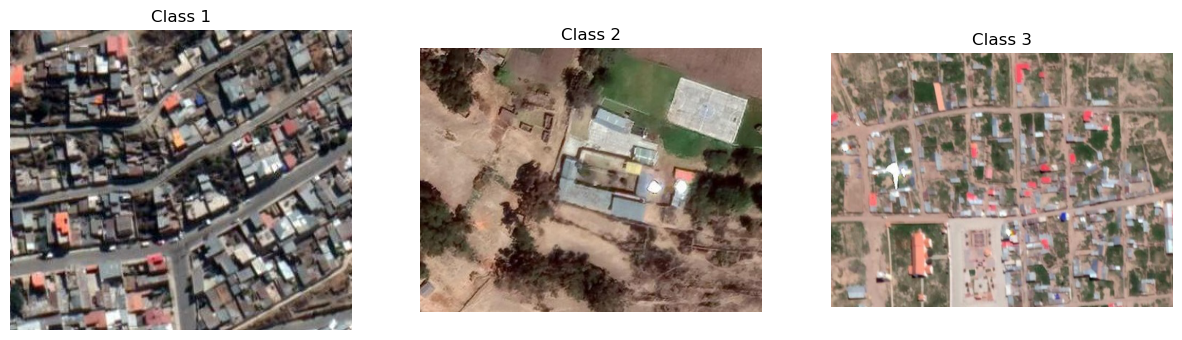

In [14]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, class_name in enumerate(["1", "2", "3"]):
    folder = processed / "Train" / f"Class_{class_name}"
    
    image_path = list(folder.glob("*.jpg"))[0]
    image = Image.open(image_path)
    
    axes[i].imshow(image)
    axes[i].set_title(f"Class {class_name}")
    axes[i].axis("off")

plt.show()

In [15]:
for class_name in ["1", "2", "3"]:
    folder = processed / "Train" / f"Class_{class_name}"
    image_path = list(folder.glob("*.jpg"))[0]
    
    image = Image.open(image_path)
    
    print(f"Class {class_name}")
    print("Size:", image.size)
    print("Mode:", image.mode)
    print()

Class 1
Size: (324, 284)
Mode: RGB

Class 2
Size: (468, 362)
Mode: RGB

Class 3
Size: (623, 462)
Mode: RGB



In [17]:
%pip install tensorflow


  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.8/351.2 MB 2.1 MB/s eta 0:02:51
   ---------------------------------------- 0.8/351.2 MB 2.1 MB/s eta 0:02:51
   ---------------------------------------- 1.0/351.2 MB 1.1 MB/s eta 0:05:24
   ---------------------------------------- 1.3/351.2 MB 1.2 MB/s eta 0:04:50
   ---------------------------------------- 1.3/351.2 MB 1.2 MB/s eta 0:04:50
   ---------------------------------------- 1.3/351.2 MB 1.2 MB/s eta 0:04:50
   ---------------------------------------- 1.3/351.2 MB 1.2 MB/s eta 0:04:50
   ---------------------------------------- 1.3/351.2 MB 1.2 MB/s eta 0:04:50
   ---------------------------------------- 1.3/351.2 MB 1.2 MB/s eta 0:04:50
   -------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.36.2 which is incompatible.


In [18]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [19]:
from pathlib import Path

processed = Path(r"D:\Users\91638\OneDrive\Desktop\Poverty_mapping\Processed_Dataset")

print("Processed dataset exists:", processed.exists())

Processed dataset exists: True


In [20]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    processed / "Train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    processed / "Validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    processed / "Test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Classes:", train_ds.class_names)

Found 5230 files belonging to 3 classes.
Found 1120 files belonging to 3 classes.
Found 1123 files belonging to 3 classes.
Classes: ['Class_1', 'Class_2', 'Class_3']


In [21]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

print("Normalization completed!")

Normalization completed!


In [22]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

print("Data augmentation created successfully!")

Data augmentation created successfully!


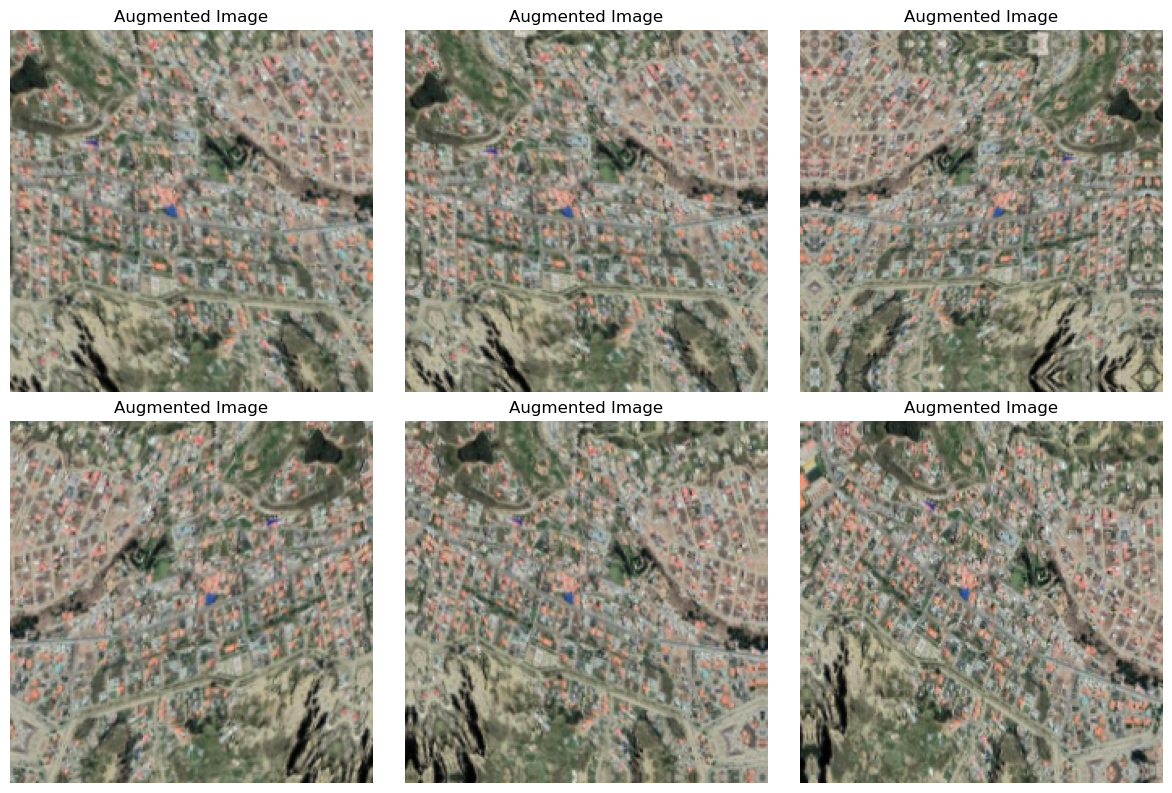

In [23]:
import matplotlib.pyplot as plt

# Take one batch from the training dataset
images, labels = next(iter(train_ds))

# Take the first image
sample_image = images[0]

plt.figure(figsize=(12, 8))

for i in range(6):
    augmented_image = data_augmentation(
        tf.expand_dims(sample_image, 0),
        training=True
    )[0]

    plt.subplot(2, 3, i + 1)
    plt.imshow(augmented_image)
    plt.axis("off")
    plt.title("Augmented Image")

plt.tight_layout()
plt.show()

In [25]:
model = tf.keras.Sequential([
    
    # Data Augmentation
    data_augmentation,

    # First CNN block
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu',
                           input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Second CNN block
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Third CNN block
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Feature extraction
    tf.keras.layers.GlobalAveragePooling2D(),

    # Classification
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    # 3 classes
    tf.keras.layers.Dense(3, activation='softmax')
])

model.summary()

C:\Users\91638\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (1, 224, 224, 3)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (1, 222, 222, 32)           │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (1, 111, 111, 32)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (1, 109, 109, 64)           │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (1, 54, 54, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (1, 52, 52, 128)            │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (1, 26, 26, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (1, 128)                    │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (1, 128)                    │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (1, 128)                    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (1, 3)                      │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 110,147 (430.26 KB)

 Trainable params: 110,147 (430.26 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully with Adam!")

Model compiled successfully with Adam!


In [28]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_adam = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping]
)

Epoch 1/30


C:\Users\91638\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


164/164 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.8614 - loss: 0.3504 - val_accuracy: 0.8616 - val_loss: 0.3595
Epoch 2/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 149s 695ms/step - accuracy: 0.8671 - loss: 0.3466 - val_accuracy: 0.7884 - val_loss: 0.4417
Epoch 3/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 132s 804ms/step - accuracy: 0.8709 - loss: 0.3288 - val_accuracy: 0.7759 - val_loss: 0.5404
Epoch 4/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 145s 825ms/step - accuracy: 0.8717 - loss: 0.3211 - val_accuracy: 0.8813 - val_loss: 0.3120
Epoch 5/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 136s 828ms/step - accuracy: 0.8730 - loss: 0.3116 - val_accuracy: 0.8982 - val_loss: 0.2775
Epoch 6/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 135s 824ms/step - accuracy: 0.8839 - loss: 0.2994 - val_accuracy: 0.7188 - val_loss: 0.8105
Epoch 7/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 134s 813ms/step - accuracy: 0.8836 - loss: 0.2945 - val_accuracy: 0.8125 - val_loss: 0.4574
Epoch 8/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 162s 991ms/step - accuracy: 0.8786 - loss: 0.3046 

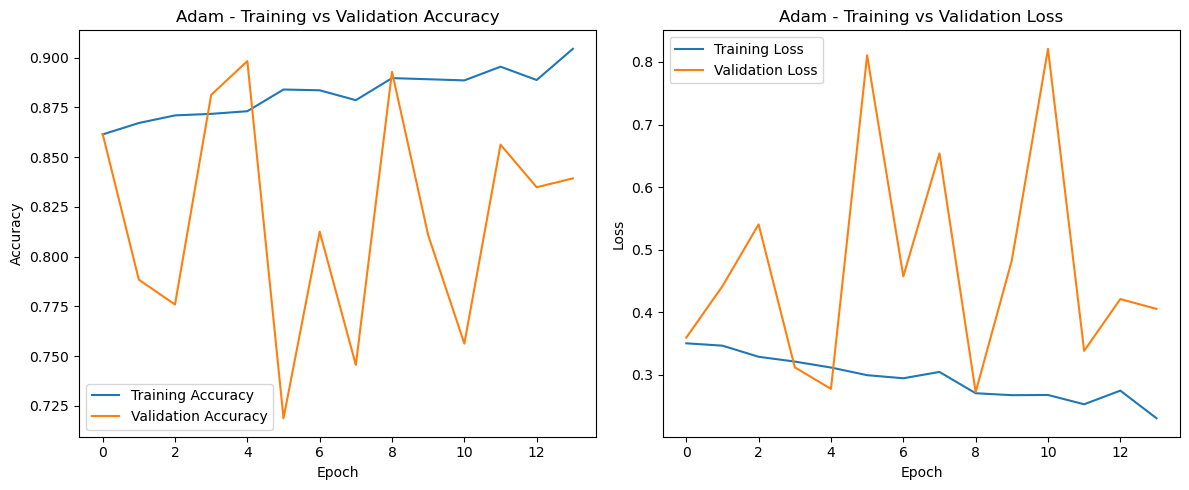

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_adam.history['accuracy'], label='Training Accuracy')
plt.plot(history_adam.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Adam - Training vs Validation Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_adam.history['loss'], label='Training Loss')
plt.plot(history_adam.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Adam - Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [30]:
best_epoch = history_adam.history['val_loss'].index(
    min(history_adam.history['val_loss'])
) + 1

best_val_loss = min(history_adam.history['val_loss'])
best_val_accuracy = max(history_adam.history['val_accuracy'])

print("Best Epoch:", best_epoch)
print("Best Validation Loss:", best_val_loss)
print("Best Validation Accuracy:", best_val_accuracy)

Best Epoch: 9
Best Validation Loss: 0.27240481972694397
Best Validation Accuracy: 0.8982142806053162


In [31]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Adam Test Loss:", test_loss)
print("Adam Test Accuracy:", test_accuracy)

36/36 ━━━━━━━━━━━━━━━━━━━━ 22s 584ms/step - accuracy: 0.8673 - loss: 0.3216
Adam Test Loss: 0.3215886056423187
Adam Test Accuracy: 0.8673197031021118


In [33]:
import numpy as np
from sklearn.metrics import classification_report

# True labels
y_true = np.concatenate([y.numpy() for x, y in test_ds])

# Predicted probabilities
y_pred_prob = model.predict(test_ds)

# Convert probabilities to class numbers
y_pred = np.argmax(y_pred_prob, axis=1)

# Classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=['Class_1', 'Class_2', 'Class_3']
))

36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 515ms/step
              precision    recall  f1-score   support

     Class_1       0.88      0.85      0.86       291
     Class_2       0.87      0.86      0.86       532
     Class_3       0.86      0.91      0.88       300

    accuracy                           0.87      1123
   macro avg       0.87      0.87      0.87      1123
weighted avg       0.87      0.87      0.87      1123



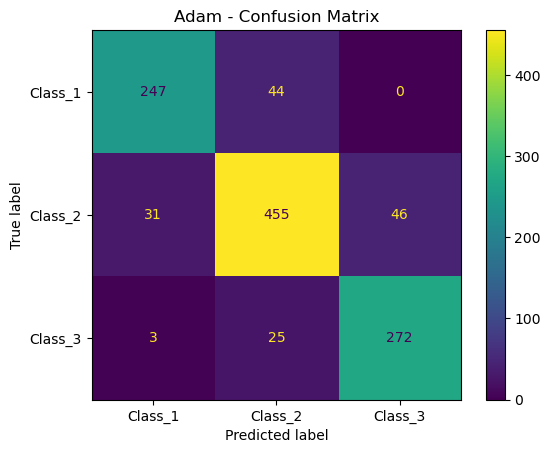

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Class_1', 'Class_2', 'Class_3']
)

disp.plot()
plt.title("Adam - Confusion Matrix")
plt.show()

In [35]:
rmsprop_model = tf.keras.Sequential([
    
    # Data Augmentation
    data_augmentation,

    # First CNN block
    tf.keras.layers.Conv2D(
        32, (3, 3), activation='relu',
        input_shape=(224, 224, 3)
    ),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Second CNN block
    tf.keras.layers.Conv2D(
        64, (3, 3), activation='relu'
    ),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Third CNN block
    tf.keras.layers.Conv2D(
        128, (3, 3), activation='relu'
    ),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Feature extraction
    tf.keras.layers.GlobalAveragePooling2D(),

    # Classification
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    # 3 classes
    tf.keras.layers.Dense(3, activation='softmax')
])

rmsprop_model.summary()

C:\Users\91638\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (1, 224, 224, 3)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (1, 222, 222, 32)           │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (1, 111, 111, 32)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (1, 109, 109, 64)           │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (1, 54, 54, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (1, 52, 52, 128)            │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (1, 26, 26, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (1, 128)                    │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (1, 128)                    │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (1, 128)                    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (1, 3)                      │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 110,147 (430.26 KB)

 Trainable params: 110,147 (430.26 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
rmsprop_model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("RMSprop model compiled successfully!")

RMSprop model compiled successfully!


In [37]:
early_stopping_rmsprop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_rmsprop = rmsprop_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping_rmsprop]
)

Epoch 1/30


C:\Users\91638\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


164/164 ━━━━━━━━━━━━━━━━━━━━ 167s 975ms/step - accuracy: 0.4700 - loss: 1.0498 - val_accuracy: 0.4732 - val_loss: 1.0116
Epoch 2/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 122s 740ms/step - accuracy: 0.4908 - loss: 0.9691 - val_accuracy: 0.4545 - val_loss: 0.9916
Epoch 3/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 147s 769ms/step - accuracy: 0.5444 - loss: 0.8823 - val_accuracy: 0.6821 - val_loss: 0.7415
Epoch 4/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 122s 743ms/step - accuracy: 0.6335 - loss: 0.7749 - val_accuracy: 0.7018 - val_loss: 0.6379
Epoch 5/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 147s 774ms/step - accuracy: 0.6843 - loss: 0.7093 - val_accuracy: 0.6616 - val_loss: 0.7754
Epoch 6/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 123s 750ms/step - accuracy: 0.7254 - loss: 0.6436 - val_accuracy: 0.7125 - val_loss: 0.6103
Epoch 7/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 147s 779ms/step - accuracy: 0.7551 - loss: 0.5974 - val_accuracy: 0.7866 - val_loss: 0.5417
Epoch 8/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 131s 794ms/step - accuracy: 0.7631 - loss: 0.58

In [38]:
best_epoch_rmsprop = history_rmsprop.history['val_loss'].index(
    min(history_rmsprop.history['val_loss'])
) + 1

best_val_loss_rmsprop = min(history_rmsprop.history['val_loss'])
best_val_accuracy_rmsprop = max(history_rmsprop.history['val_accuracy'])

print("Best RMSprop Epoch:", best_epoch_rmsprop)
print("Best RMSprop Validation Loss:", best_val_loss_rmsprop)
print("Best RMSprop Validation Accuracy:", best_val_accuracy_rmsprop)

Best RMSprop Epoch: 9
Best RMSprop Validation Loss: 0.4537799656391144
Best RMSprop Validation Accuracy: 0.8187500238418579


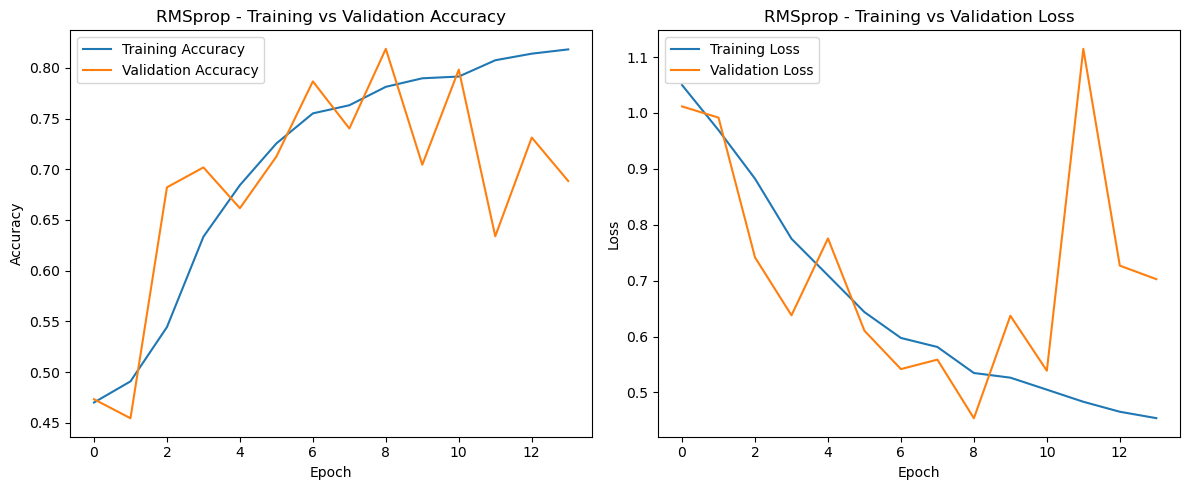

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_rmsprop.history['accuracy'], label='Training Accuracy')
plt.plot(history_rmsprop.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('RMSprop - Training vs Validation Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_rmsprop.history['loss'], label='Training Loss')
plt.plot(history_rmsprop.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RMSprop - Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [40]:
test_loss_rmsprop, test_accuracy_rmsprop = rmsprop_model.evaluate(test_ds)

print("RMSprop Test Loss:", test_loss_rmsprop)
print("RMSprop Test Accuracy:", test_accuracy_rmsprop)

36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 539ms/step - accuracy: 0.8166 - loss: 0.4858
RMSprop Test Loss: 0.4857903718948364
RMSprop Test Accuracy: 0.8165627717971802


In [41]:
import numpy as np
from sklearn.metrics import classification_report

y_true_rmsprop = np.concatenate([y.numpy() for x, y in test_ds])

y_pred_prob_rmsprop = rmsprop_model.predict(test_ds)
y_pred_rmsprop = np.argmax(y_pred_prob_rmsprop, axis=1)

print(classification_report(
    y_true_rmsprop,
    y_pred_rmsprop,
    target_names=['Class_1', 'Class_2', 'Class_3']
))

36/36 ━━━━━━━━━━━━━━━━━━━━ 18s 490ms/step
              precision    recall  f1-score   support

     Class_1       0.74      0.82      0.78       291
     Class_2       0.86      0.81      0.83       532
     Class_3       0.83      0.82      0.82       300

    accuracy                           0.82      1123
   macro avg       0.81      0.82      0.81      1123
weighted avg       0.82      0.82      0.82      1123



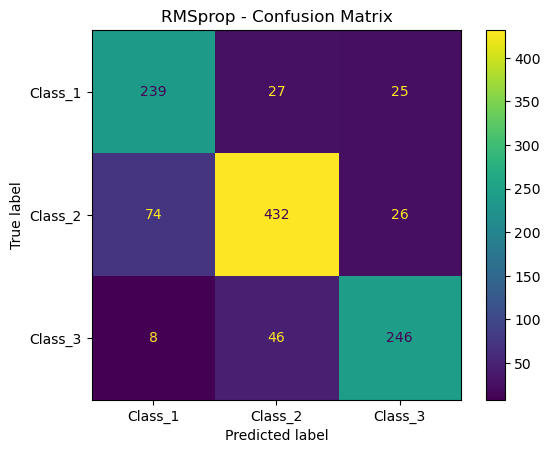

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rmsprop = confusion_matrix(
    y_true_rmsprop,
    y_pred_rmsprop
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rmsprop,
    display_labels=['Class_1', 'Class_2', 'Class_3']
)

disp.plot()
plt.title("RMSprop - Confusion Matrix")
plt.show()